UAU+SIR model (multiplex network)  意识降低感染 无迁移


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================================
# 微观马尔可夫链（MMC） UAU-SIR 模型（核心函数，与原代码一致）
# ============================================================================
def mmc_simulation(Time, info_net, disease_net, params, seed=None):
    """
    参数:
        Time: 模拟步数
        info_net:  信息层邻接表（每个节点的入邻居列表）
        disease_net: 疾病层邻接表
        params: 包含 lambda1, mu1, beta_U, beta_A, mu2 的字典
        seed:   随机种子（用于初始感染选择）
    返回:
        history: (Time, 5) 数组，每列为全局平均概率
    """
    lambda1 = params["lambda1"]
    delta   = params["mu1"]
    beta_U  = params["beta_U"]
    beta_A  = params["beta_A"]
    mu      = params["mu2"]

    N = len(info_net)
    states = np.zeros((N, 5))

    # ---------- 初始条件（使用指定种子，确保可重复）----------
    if seed is not None:
        np.random.seed(seed)
    init_inf = np.random.choice(N, size=int(0.01 * N), replace=False)
    states[:, 0] = 1.0
    states[init_inf, 0] = 0.0
    states[init_inf, 2] = 1.0   # AI

    history = np.zeros((Time, 5))

    for t in range(Time):
        history[t] = np.mean(states, axis=0)

        US, AS, AI, UR, AR = states.T
        P_A  = AS + AI + AR
        P_AI = AI

        new_states = np.zeros_like(states)

        for i in range(N):
            # 信息层：r_i
            r = 1.0
            for j in info_net[i]:
                r *= (1 - lambda1 * P_A[j])
            
            # 疾病层：qA, qU
            qA = 1.0
            qU = 1.0
            for j in disease_net[i]:
                qA *= (1 - beta_A * P_AI[j])
                qU *= (1 - beta_U * P_AI[j])

            us = US[i]
            a_s = AS[i]
            a_i = AI[i]
            u_r = UR[i]
            a_r = AR[i]

            new_AS = a_s * (1 - delta) * qA + us * (1 - r) * qA
            new_US = a_s * delta * qU + us * r * qU
            new_AI = (a_s * ((1 - delta) * (1 - qA) + delta * (1 - qU)) +
                      us * (r * (1 - qU) + (1 - r) * (1 - qA)) +
                      a_i * (1 - mu))
            new_AR = (a_i * (1 - delta) * mu +
                      a_r * (1 - delta) +
                      u_r * (1 - r))
            new_UR = (a_i * delta * mu +
                      a_r * delta +
                      u_r * r)

            new_states[i, 0] = new_US
            new_states[i, 1] = new_AS
            new_states[i, 2] = new_AI
            new_states[i, 3] = new_UR
            new_states[i, 4] = new_AR

        row_sum = new_states.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        states = new_states / row_sum

    return history


# ============================================================================
# 生成无向 ER 网络，返回邻接表
# ============================================================================
def generate_er_network(N, avg_deg, seed=None):
    p = avg_deg / (N - 1) if N > 1 else 0
    p = min(p, 1.0)
    G = nx.erdos_renyi_graph(N, p, seed=seed, directed=False)
    return [list(G.neighbors(i)) for i in range(N)]


# ============================================================================
# 多次重复实验主程序
# ============================================================================
if __name__ == "__main__":
    # -------------------- 固定参数设置 --------------------
    Time = 150
    N = 3000          # 节点数（为了200次仿真速度，可适当降低，如1000）
    num_simulations = 20

    avg_deg_info = 10       # 信息网络平均度
    avg_deg_disease = 10   # 疾病网络平均度

    params = {
        "lambda1": 0.2,
        "mu1": 0.15,
        "beta_U": 0.3,
        "beta_A": 0.1,
        "mu2": 0.15
    }

    # -------------------- 存储所有仿真结果 --------------------
    # 维度: (num_simulations, Time, 5)
    all_history = np.zeros((num_simulations, Time, 5))

    # -------------------- 循环重复实验 --------------------
    base_seed = 42  # 基础随机种子

    for sim in range(num_simulations):
        # 1. 生成双层网络（每次使用不同种子，保证独立）
        seed_info = base_seed + sim * 2
        seed_disease = base_seed + sim * 2 + 1
        info_adj = generate_er_network(N, avg_deg_info, seed=seed_info)
        disease_adj = generate_er_network(N, avg_deg_disease, seed=seed_disease)

        # 2. 运行单次仿真（传入随机种子，控制初始感染）
        history = mmc_simulation(Time, info_adj, disease_adj, params, seed=sim)

        # 3. 存储结果
        all_history[sim] = history

        # 可选：打印进度
        # if (sim + 1) % 20 == 0:
        #     print(f"已完成 {sim + 1} / {num_simulations} 次仿真")

    # -------------------- 统计结果 --------------------
    mean_history = all_history.mean(axis=0)          # (Time, 5)

    # -------------------- 保存均值与置信区间 --------------------
    df_mean = pd.DataFrame(mean_history, columns=["US", "AS", "AI", "UR", "AR"])

    df_mean.to_csv("UAU_SIR_mean.csv", index=False)

    print("200次重复实验完成，统计结果已保存。")



200次重复实验完成，统计结果已保存。


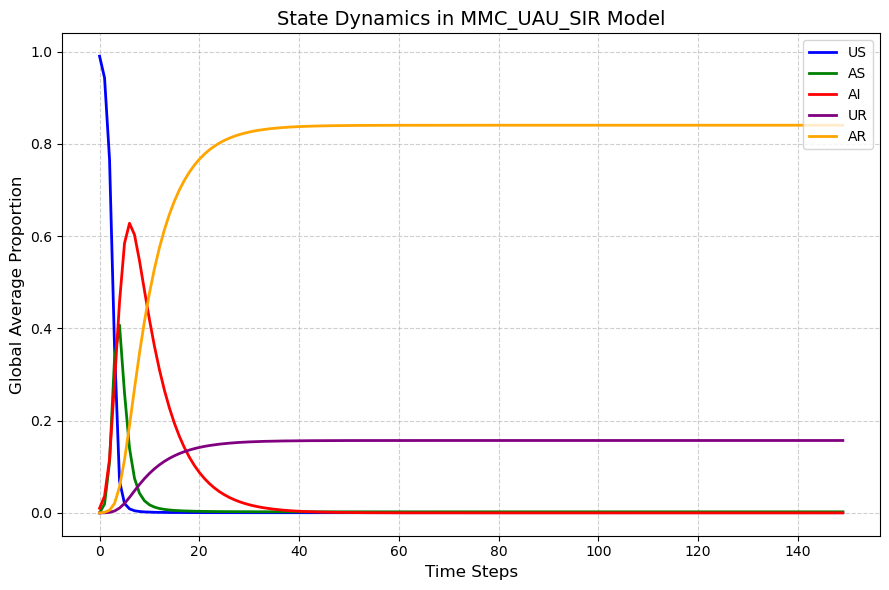

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 MIR 基线模型的输出 CSV 文件
# ============================================
file_name = "UAU_SIR_mean.csv"  # 请根据实际文件名修改
df = pd.read_csv(file_name)

# ============================================
# 2. 设置颜色映射（与模板完全一致）
# ============================================
state_colors = {
    'US': 'blue',
    'AS': 'green',
    'AI': 'red',
    'UR': 'purple',
    'AR': 'orange'
}
state_labels = ['US', 'AS', 'AI', 'UR', 'AR']  # 顺序必须与 df 列顺序一致

# ============================================
# 3. 创建画布并绘制各状态曲线
# ============================================
plt.figure(figsize=(9, 6))

for i, label in enumerate(state_labels):
    plt.plot(
        df.index,                 # 时间步（行索引）
        df[label],               # 该状态全局比例
        label=label,
        color=state_colors[label],
        linewidth=2
    )

# ============================================
# 4. 图表装饰（模仿模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('State Dynamics in MMC_UAU_SIR Model', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('MIR_UAU_SIR_single_run.png', dpi=300, bbox_inches='tight')
plt.show()